# SAAM Project 2026
## 0. Setup
Imports, Paths, Config & Helper Functions 

This cell should be run first.
It loads the libraries, sets the main paths and parameters, and defines the helper functions used later in the notebook.

In [48]:
import re
import warnings
from pathlib import Path
import numpy as np
import pandas as pd
import cvxpy as cp
import matplotlib.pyplot as plt

# =============================================================================
# Paths
# =============================================================================

BASE_DIR = Path.cwd()
RAW_DIR = BASE_DIR / "csv_raw_data"
CLEAN_DIR = BASE_DIR / "cleaned_data"
OUT_DIR = BASE_DIR / "results"

# Create output folders if they do not already exist
CLEAN_DIR.mkdir(parents=True, exist_ok=True)
OUT_DIR.mkdir(parents=True, exist_ok=True)


# =============================================================================
# Project settings
# =============================================================================

REGIONS = ["AMER", "EUR"]

START_YEAR = 2013
END_YEAR = 2024
WINDOW_YEARS = 10
MIN_VALID_MONTHS = 36
STALE_THRESHOLD = 0.50

# Raw files
STATIC_FILE = "Static_2025.csv"
RI_FILE = "DS_RI_T_USD_M_2025.csv"
MV_FILE = "DS_MV_T_USD_M_2025.csv"
CO2_FILE = "DS_CO2_SCOPE_1_Y_2025.csv"
REV_FILE = "DS_REV_Y_2025.csv"

# Cleaned/output files
RI_PRICES_FILE = "cleaned_RI_monthly_prices.csv"
RI_RETURNS_FILE = "cleaned_RI_monthly_returns.csv"
MV_CLEAN_FILE = "cleaned_MV_monthly.csv"
CO2_CLEAN_FILE = "cleaned_CO2_scope1_yearly.csv"
REV_CLEAN_FILE = "cleaned_REV_yearly.csv"
INV_SET_FILE = "investment_set_by_year.csv"
MVP_W_FILE = "mvp_weights_by_year.csv"
MVP_RET_FILE = "mvp_monthly_returns.csv"
VW_RET_FILE = "vw_monthly_returns.csv"


# =============================================================================
# Helper functions
# =============================================================================

def clean_headers(df):
    # Remove extra spaces from column names
    df.columns = [str(c).strip() for c in df.columns]
    return df


def get_id_cols(df):
    # Find the NAME and ISIN columns
    upper = {c.upper(): c for c in df.columns}
    return upper.get("NAME"), upper.get("ISIN")


def get_time_cols(df):
    # Return all columns except NAME and ISIN
    name_col, isin_col = get_id_cols(df)
    exclude = {c for c in [name_col, isin_col] if c is not None}
    return [c for c in df.columns if c not in exclude]


def sort_month_cols(cols):
    # Sort monthly columns in time order
    try:
        dt = pd.to_datetime(cols, errors="coerce")
        if dt.notna().all():
            return [c for _, c in sorted(zip(dt, cols))]
        return sorted(cols)
    except Exception:
        return sorted(cols)


def sort_year_cols(cols):
    # Sort yearly columns in time order
    def parse_year(x):
        try:
            return int(str(x)[:4])
        except Exception:
            return 999999
    return sorted(cols, key=parse_year)


def get_december_col(month_cols, year):
    # Return the December column for a given year
    dts = pd.to_datetime(month_cols, errors="coerce")
    candidates = [c for c, d in zip(month_cols, dts)
                  if pd.notna(d) and d.year == year and d.month == 12]
    return candidates[-1] if candidates else None


def get_trailing_window_cols(month_cols, end_year, window_years=10):
    # Return the monthly columns in the rolling estimation window
    # Example: if end_year = 2013, this gives Jan 2004 to Dec 2013
    end_dt = pd.Timestamp(f"{end_year}-12-31")
    start_dt = end_dt - pd.DateOffset(years=window_years)
    col_dates = pd.to_datetime(month_cols, errors="coerce")

    return [c for c, d in zip(month_cols, col_dates)
            if pd.notna(d) and start_dt < d <= end_dt]


def get_investment_year_cols(month_cols, investment_year):
    # Return the monthly columns in the investment year
    col_dates = pd.to_datetime(month_cols, errors="coerce")
    return [c for c, d in zip(month_cols, col_dates)
            if pd.notna(d) and d.year == investment_year]


def drop_empty_timeseries_rows(df):
    # Remove firms where all time-series values are missing
    df = clean_headers(df)
    _, isin_col = get_id_cols(df)
    time_cols = get_time_cols(df)

    df = df.dropna(subset=[isin_col]).copy()
    df[time_cols] = df[time_cols].apply(pd.to_numeric, errors="coerce")

    return df.loc[~df[time_cols].isna().all(axis=1)].copy()


def keep_isins(df, valid_isins):
    # Keep only firms in the chosen ISIN set
    _, isin_col = get_id_cols(df)
    return df[df[isin_col].isin(valid_isins)].copy()


def annual_forward_fill(df):
    # Forward-fill annual data using the previous available year.
    # Note: Only fills middle/end gaps, NOT beginning gaps (per project requirements).
    out = df.copy()
    year_cols = sort_year_cols(get_time_cols(out))
    out[year_cols] = out[year_cols].apply(pd.to_numeric, errors="coerce")
    out[year_cols] = out[year_cols].ffill(axis=1)
    return out


def detect_delisting(df):
    # Some companies include delisting information in the NAME column.
    # If we find a date in the name, we assume that is the delisting date
    # and set the price to 0 from that point onward.
    #
    # If the name only says "DEAD", we set the first month after the last
    # observed price to 0.
    #
    # This ensures we correctly capture the -100% return when a firm delists.

    out = df.copy()
    name_col, _ = get_id_cols(out)

    if name_col is None:
        return out

    month_cols = sort_month_cols(get_time_cols(out))
    month_dates = pd.to_datetime(month_cols, errors="coerce")

    # Look for a date in the format DD/MM/YYYY inside the name
    date_pattern = re.compile(r"\d{2}/\d{2}/\d{4}")

    for idx in out.index:
        name = str(out.at[idx, name_col]).upper()

        # Case 1: name contains both a date and the word "DELIST"
        if "DELIST" in name:
            match = date_pattern.search(name)

            if match:
                try:
                    delist_date = pd.to_datetime(match.group(), dayfirst=True)
                except:
                    continue

                for col, dt in zip(month_cols, month_dates):
                    if pd.notna(dt) and dt >= delist_date:
                        out.at[idx, col] = 0.0

        # Case 2: name contains "DEAD" but no date
        elif "DEAD" in name:
            values = out.loc[idx, month_cols]
            last_valid = values.last_valid_index()

            if last_valid is not None and last_valid != month_cols[-1]:
                next_pos = month_cols.index(last_valid) + 1
                out.at[idx, month_cols[next_pos]] = 0.0

    return out

def compute_monthly_returns(ri_prices):
    # Compute simple monthly returns from cleaned RI prices.
    # Standard: R_t = P_t / P_{t-1} - 1
    # Delisting: R = -1.0 (price goes to 0)
    # Gap: R = NaN

    df = ri_prices.copy()
    name_col, isin_col = get_id_cols(df)
    month_cols = sort_month_cols(get_time_cols(df))
    id_cols_list = [c for c in [name_col, isin_col] if c is not None]

    returns = df[id_cols_list].copy()

    for i, col in enumerate(month_cols):
        if i == 0:
            returns[col] = np.nan
            continue

        prev_col = month_cols[i - 1]
        prev = df[prev_col].values.astype(float)
        curr = df[col].values.astype(float)
        ret = np.full(len(df), np.nan)

        valid = (~np.isnan(prev)) & (prev > 0) & (~np.isnan(curr)) & (curr > 0)
        ret[valid] = curr[valid] / prev[valid] - 1.0

        delist = (curr == 0.0) & (~np.isnan(prev)) & (prev > 0)
        ret[delist] = -1.0

        returns[col] = ret

    return returns


def flag_stale_prices(returns_df, end_year, window_years=10, threshold=0.50):
    # Return a DataFrame with stale-price diagnostics per firm over the
    # trailing window_years-year window ending December of end_year.

    _, isin_col = get_id_cols(returns_df)
    month_cols = sort_month_cols(get_time_cols(returns_df))
    window_cols = get_trailing_window_cols(
        month_cols, end_year=end_year, window_years=window_years
    )

    # If no valid trailing window is found, return an empty diagnostics table
    if not window_cols:
        return pd.DataFrame(columns=["ISIN", "n_valid", "n_zero", "zero_frac", "stale_flag"])

    # Keep only the returns in the estimation window
    data = returns_df[window_cols].apply(pd.to_numeric, errors="coerce")

    # Count available observations and zero returns for each firm
    n_valid = data.notna().sum(axis=1)
    n_zero = (data == 0.0).sum(axis=1)
    zero_frac = n_zero / n_valid.replace(0, np.nan)

    out = pd.DataFrame({
        "ISIN": returns_df[isin_col].values,
        "n_valid": n_valid.values,
        "n_zero": n_zero.values,
        "zero_frac": zero_frac.values,
    })

    # Flag firms with too many zero returns as stale-price firms
    out["stale_flag"] = out["zero_frac"] > threshold

    return out


def estimate_moments(ri_ret_by_isin, isins, window_cols):
    # Estimate mean returns and pairwise covariance matrix over the estimation window.
    ret_mat = (
        ri_ret_by_isin.reindex(isins)[window_cols]
        .apply(pd.to_numeric, errors="coerce")
    )

    # Convert to matrix (tau x N) for pandas operations
    R = ret_mat.T 
    
    # Mean returns (ignoring NaNs)
    mu = R.mean(axis=0).values

    # Pairwise covariance (Pandas handles NaNs automatically)
    cov = R.cov().values

    # Pandas cov is unbiased (divides by N-1). Convert to biased (divides by N)
    tau = float(R.shape[0])
    cov = cov * ((tau - 1) / tau)
    
    # Replace any NaNs in covariance matrix with 0 (edge cases for disjoint series)
    cov = np.nan_to_num(cov)

    # Ensure covariance is well-behaved (numerical stability)
    cov = 0.5 * (cov + cov.T)
    eigvals, eigvecs = np.linalg.eigh(cov)
    cov = eigvecs @ np.diag(np.clip(eigvals, 1e-8, None)) @ eigvecs.T
    cov = 0.5 * (cov + cov.T)

    return mu, cov, isins


def solve_mvp(cov):
    # Solve long-only minimum variance portfolio

    n = cov.shape[0]
    w = cp.Variable(n)

    prob = cp.Problem(
        cp.Minimize(cp.quad_form(w, cp.psd_wrap(cov))),
        [cp.sum(w) == 1, w >= 0]
    )

    prob.solve(solver=cp.OSQP, verbose=False)

    if prob.status not in ["optimal", "optimal_inaccurate"]:
        raise RuntimeError(f"MVP optimisation failed: {prob.status}")

    weights = np.clip(np.array(w.value).flatten(), 0, None)

    return weights / weights.sum()


def summary_stats(series, name, rf_monthly):
    # Compute annualised performance statistics from a monthly return series.
    ann = 12
    vals = series.to_numpy(dtype=float)
    mu = vals.mean()
    std = vals.std(ddof=1)
    excess_return = mu - rf_monthly


    return {
        "portfolio": name,
        "start_date": series.index.min().strftime("%Y-%m"),
        "end_date": series.index.max().strftime("%Y-%m"),
        "n_months": len(vals),
        "ann_mean_return": mu * ann,
        "ann_volatility": std * np.sqrt(ann),
        "sharpe_ratio": np.nan if std == 0 else (excess_return / std) * np.sqrt(ann),        
        "min_monthly_return": vals.min(),
        "max_monthly_return": vals.max(),
    }



# Part I - Standard Portfolio Allocation
## 1. Data Cleaning

Raw Datastream files are loaded and cleaned in five steps:
1. Filter to the assigned region universe (North America + Europe)
2. Detect and handle delisted firms (price set to 0, return = -100%)
3. Treat RI prices below 0.5 as missing to avoid infinite returns
4. Forward-fill missing annual CO2 and revenue data (middle/end gaps only)
5. Intersect a common ISIN universe across all files

Note: stale-price screening is **not** applied here — it is applied year-by-year in Cell 2 to avoid any look-ahead bias.

In [49]:

# 1. LOAD RAW FILES
static = clean_headers(pd.read_csv(RAW_DIR / STATIC_FILE))
ri     = clean_headers(pd.read_csv(RAW_DIR / RI_FILE))
mv     = clean_headers(pd.read_csv(RAW_DIR / MV_FILE))
co2    = clean_headers(pd.read_csv(RAW_DIR / CO2_FILE))
rev    = clean_headers(pd.read_csv(RAW_DIR / REV_FILE))

# 2. FILTER STATIC TO ASSIGNED REGIONS
static_name_col, static_isin_col = get_id_cols(static)
if static_isin_col is None:
    raise ValueError("Static file must contain an ISIN column.")
if "Region" not in static.columns:
    raise ValueError("Static file must contain a 'Region' column.")

static = static.dropna(subset=[static_isin_col]).copy()
static = static[static["Region"].isin(REGIONS)].copy()

# 3. DROP ROWS WITH NO TIME-SERIES DATA AT ALL
ri  = drop_empty_timeseries_rows(ri)
mv  = drop_empty_timeseries_rows(mv)
co2 = drop_empty_timeseries_rows(co2)
rev = drop_empty_timeseries_rows(rev)

# 4. RESTRICT TO REGION UNIVERSE
region_isins = set(static[static_isin_col])
ri  = keep_isins(ri,  region_isins)
mv  = keep_isins(mv,  region_isins)
co2 = keep_isins(co2, region_isins)
rev = keep_isins(rev, region_isins)

# 5. CLEAN RI: delisting -> low prices -> compute returns
ri_month_cols = sort_month_cols(get_time_cols(ri))
ri[ri_month_cols] = ri[ri_month_cols].apply(pd.to_numeric, errors="coerce")

# Delisting must be flagged BEFORE the low-price filter (delist sets price to exact 0)
ri = detect_delisting(ri)

# Treat prices in (0, 0.5) as missing; preserve exact 0.0 for delisted firms
for c in ri_month_cols:
    mask = (ri[c] < 0.5) & (ri[c] > 0)
    ri.loc[mask, c] = np.nan

ri     = ri.loc[~ri[ri_month_cols].isna().all(axis=1)].copy()
ri_ret = compute_monthly_returns(ri)

# 6. CLEAN MV (numeric conversion only; no fill needed for monthly data)
mv_month_cols = sort_month_cols(get_time_cols(mv))
mv[mv_month_cols] = mv[mv_month_cols].apply(pd.to_numeric, errors="coerce")

# 7. FORWARD-FILL ANNUAL DATA (middle/end gaps only; beginning gaps stay NaN)
co2 = annual_forward_fill(co2)
rev = annual_forward_fill(rev)

# 8. INTERSECT COMMON ISIN UNIVERSE ACROSS ALL FILES
_, ri_isin_col  = get_id_cols(ri)
_, mv_isin_col  = get_id_cols(mv)
_, co2_isin_col = get_id_cols(co2)
_, rev_isin_col = get_id_cols(rev)

common_isins = (
    set(static[static_isin_col])
    & set(ri[ri_isin_col])
    & set(mv[mv_isin_col])
    & set(co2[co2_isin_col])
    & set(rev[rev_isin_col])
)
# NOTE: stale-price screening is NOT applied globally here.
# It must be done year-by-year in Cell 2 to avoid look-ahead bias.

static = keep_isins(static, common_isins).sort_values(static_isin_col).reset_index(drop=True)
ri     = keep_isins(ri,     common_isins).sort_values(ri_isin_col).reset_index(drop=True)
ri_ret = keep_isins(ri_ret, common_isins).sort_values(ri_isin_col).reset_index(drop=True)
mv     = keep_isins(mv,     common_isins).sort_values(mv_isin_col).reset_index(drop=True)
co2    = keep_isins(co2,    common_isins).sort_values(co2_isin_col).reset_index(drop=True)
rev    = keep_isins(rev,    common_isins).sort_values(rev_isin_col).reset_index(drop=True)

# 9. SAVE
static.to_csv(CLEAN_DIR / "cleaned_static.csv", index=False)
ri.to_csv(    CLEAN_DIR / RI_PRICES_FILE,        index=False)
ri_ret.to_csv(CLEAN_DIR / RI_RETURNS_FILE,       index=False)
mv.to_csv(    CLEAN_DIR / MV_CLEAN_FILE,         index=False)
co2.to_csv(   CLEAN_DIR / CO2_CLEAN_FILE,        index=False)
rev.to_csv(   CLEAN_DIR / REV_CLEAN_FILE,        index=False)

print(f"  Common universe: {len(common_isins)} firms")
print(f"  Saved to: {CLEAN_DIR}")

C:\Users\zagor\AppData\Local\Temp\ipykernel_16572\1298326142.py:231: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  returns[col] = ret


  Common universe: 1209 firms
  Saved to: c:\Users\zagor\Vlad\M\Sustainability\Project\Sustainability-Aware-Asset-Management-Project\cleaned_data


## 2.1 Investment Set 
For each screen year Y = 2013 to 2024, define the list of firms eligible for investment in year Y+1.

### Step 1: Apply the three inclusion criteria

At the end of year Y, include a firm if and only if it satisfies all three:

**Criterion 1** - Region: corresponding region.

**Criterion 2** - Sufficient return history: the firm has at least 36 months of non-missing returns.

**Criterion 3** - Carbon data availability: the firm has carbon data (Scope 1 or Scope 2 emissions and revenues) available at the end of year Y.

### Step 2: Estimate mu and Sigma for each passing firm

Using only the valid monthly returns within the 10-year trailing window:

**Expected return**

$$\hat{\mu}_Y = \frac{1}{\omega} \sum_{k=0}^{\omega-1} R_{t-k}$$

**Covariance matrix**

$$\hat{\Sigma}_Y = \frac{1}{\omega} \sum_{k=0}^{\omega-1}
(R_{t-k} - \hat{\mu}_Y)(R_{t-k} - \hat{\mu}_Y)^\top$$

where omega = 120 (division by omega, not omega - 1).

### Step 3: Output the investment set table

Produce one row per ISIN per screen year with an investable flag.

| Column                   | Description                                  |
|--------------------------|----------------------------------------------|
| screen_year              | Year Y at which the decision is made         |
| investment_year          | Year Y+1 in which the portfolio is held      |
| ISIN                     | Firm identifier                              |
| investable_for_next_year | True / False                                 |

In [50]:
# =============================================================================
# 1. Region filter
# =============================================================================

# Load the static file (ISIN, Name, Country, Region)
static = clean_headers(pd.read_csv(RAW_DIR / STATIC_FILE))

# Keep only firms belonging to the assigned regions
region_col = [c for c in static.columns if c.upper() == "REGION"][0]
isin_col   = [c for c in static.columns if c.upper() == "ISIN"][0]

region_mask    = static[region_col].isin(REGIONS)
eligible_isins = static.loc[region_mask, isin_col].unique().tolist()

print(f"Total firms in static file : {len(static)}")
print(f"Firms after region filter  : {len(eligible_isins)}")
print(f"Regions kept               : {REGIONS}")

# =============================================================================
# 2. Sufficient return history
# =============================================================================

# Load the cleaned monthly returns
ri_returns = clean_headers(pd.read_csv(CLEAN_DIR / RI_RETURNS_FILE))

# Find the ISIN column and isolate the date columns
isin_col      = [c for c in ri_returns.columns if c.upper() == "ISIN"][0]
all_date_cols = [c for c in ri_returns.columns if c != isin_col]

# Work only on the firms that passed Criterion 1
ri_returns = ri_returns[ri_returns[isin_col].isin(eligible_isins)]
ri_returns = ri_returns.set_index(isin_col)

import warnings
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    date_index = pd.to_datetime(all_date_cols, errors="coerce")

criterion2_results = []

for year in range(START_YEAR, END_YEAR + 1):

    # The trailing window is the 10 years of monthly data ending in December of year Y.
    # Example: for Y=2013, we look at Jan 2004 to Dec 2013 (120 months).
    window_end   = pd.Timestamp(f"{year}-12-31")
    window_start = window_end - pd.DateOffset(years=WINDOW_YEARS)

    # Pick the date columns that fall strictly inside the window
    # (window_start, window_end] means we exclude the start boundary but include the end
    window_cols = [
        c for c, d in zip(all_date_cols, date_index)
        if pd.notna(d) and window_start < d <= window_end
    ]

    # Extract the return values for the window: shape (N_firms, N_months)
    window_returns = ri_returns[window_cols].apply(pd.to_numeric, errors="coerce")

    # Count how many months each firm has a non-NaN return in the window.
    # A NaN means the firm had no valid price that month (cleaned in Section 1).
    valid_months = window_returns.notna().sum(axis=1)

    # A firm passes if it has at least MIN_VALID_MONTHS (36) valid observations.
    # 36 months = 3 years, which is the minimum to get a meaningful covariance estimate.
    passes = valid_months >= MIN_VALID_MONTHS

    for isin in ri_returns.index:
        criterion2_results.append({
            "screen_year":       year,
            "ISIN":              isin,
            "valid_months":      int(valid_months[isin]),
            "passes_criterion2": bool(passes[isin]),
        })

criterion2_df = pd.DataFrame(criterion2_results)

# =============================================================================
# 3. Carbon data availability
# =============================================================================

# Load cleaned CO2 and revenue data 
co2_clean = clean_headers(pd.read_csv(CLEAN_DIR / CO2_CLEAN_FILE))
rev_clean = clean_headers(pd.read_csv(CLEAN_DIR / REV_CLEAN_FILE))

co2_clean.columns = [str(c) for c in co2_clean.columns]
rev_clean.columns = [str(c) for c in rev_clean.columns]

isin_col_co2 = [c for c in co2_clean.columns if c.upper() == "ISIN"][0]
isin_col_rev = [c for c in rev_clean.columns if c.upper() == "ISIN"][0]

co2_clean = co2_clean.set_index(isin_col_co2)
rev_clean = rev_clean.set_index(isin_col_rev)

criterion3_results = []

for year in range(START_YEAR, END_YEAR + 1):
    # Carbon data is annual, so we check if the column for year Y exists and is non-NaN.
    # Both CO2 and revenue must be available to compute carbon intensity in Part II.
    year_str = str(year)

    co2_available = co2_clean[year_str].notna() if year_str in co2_clean.columns else pd.Series(False, index=co2_clean.index)
    rev_available = rev_clean[year_str].notna() if year_str in rev_clean.columns else pd.Series(False, index=rev_clean.index)

    passes = co2_available & rev_available

    for isin in co2_clean.index:
        criterion3_results.append({
            "screen_year":       year,
            "ISIN":              isin,
            "passes_criterion3": bool(passes.get(isin, False)),
        })

criterion3_df = pd.DataFrame(criterion3_results)

# =============================================================================
# 4. Stale-price filter
# =============================================================================

# Load full returns file (not the filtered one) so flag_stale_prices can work
ri_ret_full = clean_headers(pd.read_csv(CLEAN_DIR / RI_RETURNS_FILE))

criterion4_results = []

for year in range(START_YEAR, END_YEAR + 1):
    stale_df = flag_stale_prices(ri_ret_full, end_year=year,
                                  window_years=WINDOW_YEARS,
                                  threshold=STALE_THRESHOLD)
    stale_isins = set(stale_df.loc[stale_df["stale_flag"], "ISIN"])

    for isin in eligible_isins:
        is_stale = isin in stale_isins
        criterion4_results.append({
            "screen_year":       year,
            "ISIN":              isin,
            "passes_criterion4": not is_stale,
        })

criterion4_df = pd.DataFrame(criterion4_results)

# =============================================================================
# 5. Combine criteria and estimate mu / Sigma
# =============================================================================

# Merge all four criteria into one master table
inv_set = (criterion2_df
           .merge(criterion3_df, on=["screen_year", "ISIN"])
           .merge(criterion4_df, on=["screen_year", "ISIN"])
           .merge(pd.DataFrame({"ISIN": eligible_isins}), on="ISIN"))

# investable = region (C1) AND history (C2) AND carbon (C3) AND not stale (C4)
inv_set["investable"] = (
    inv_set["passes_criterion2"] &
    inv_set["passes_criterion3"] &
    inv_set["passes_criterion4"]
)

moments_by_year = {}  # stores {"year": {"mu": ..., "cov": ..., "isins": ...}}

for year in range(START_YEAR, END_YEAR + 1):

    # ISINs that passed all criteria for this screen year
    mask   = (inv_set["screen_year"] == year) & inv_set["investable"]
    isins  = inv_set.loc[mask, "ISIN"].tolist()

    # Same trailing window as Criterion 2
    window_end   = pd.Timestamp(f"{year}-12-31")
    window_start = window_end - pd.DateOffset(years=WINDOW_YEARS)
    window_cols  = [
        c for c, d in zip(all_date_cols, date_index)
        if pd.notna(d) and window_start < d <= window_end
    ]

    # Use the corrected helper function to compute pairwise covariance
    mu, cov, valid_isins = estimate_moments(ri_returns, isins, window_cols)
    
    if len(valid_isins) == 0:
        print(f"{year}: no complete firms, skipping.")
        continue
    
    moments_by_year[year] = {"mu": mu, "cov": cov, "isins": valid_isins}
    
# =============================================================================
# 6. Output the investment set table
# =============================================================================

# Only keep firms that survived dropna() in step 2
for year, data in moments_by_year.items():
    complete_isins = data["isins"]
    inv_set.loc[
        (inv_set["screen_year"] == year) & ~inv_set["ISIN"].isin(complete_isins),
        "investable"
    ] = False

# Rename columns to match what downstream cells expect
investment_set = inv_set[["screen_year", "ISIN", "investable"]].copy()
investment_set["investment_year"] = investment_set["screen_year"] + 1
investment_set.rename(columns={"investable": "investable_for_next_year"}, inplace=True)
investment_set.to_csv(CLEAN_DIR / INV_SET_FILE, index=False)

# Sanity check of the data

from IPython.display import display

# Group by year and count the 'True' values for every criterion at once
master_summary = inv_set.groupby("screen_year")[
    ["passes_criterion2", "passes_criterion3", "passes_criterion4", "investable"]
].sum()

# Rename the rows to look professional
master_summary = master_summary.rename(columns={
    "passes_criterion2": "Passed 3-Yr History",
    "passes_criterion3": "Passed Carbon Data",
    "passes_criterion4": "Passed Stale Price",
    "investable":        "FINAL INVESTABLE"
})

# Transpose (.T) to make it horizontal and display it
display(master_summary.T)


Total firms in static file : 2545
Firms after region filter  : 1302
Regions kept               : ['AMER', 'EUR']


screen_year,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
Passed 3-Yr History,1185,1187,1187,1191,1191,1194,1195,1196,1197,1198,1198,1202
Passed Carbon Data,837,863,896,918,952,1010,1100,1143,1175,1199,1206,1209
Passed Stale Price,1209,1209,1209,1209,1209,1209,1209,1209,1209,1209,1209,1209
FINAL INVESTABLE,829,855,887,912,944,1000,1090,1134,1167,1189,1195,1202


## 2.2 MVP

We determine the allocation at the end of each year Y for the next year Y+1. The weights have to add up to 1 and be bigger or equal to 0 when solving for the MVP Minimization problem:

$$\min_{\alpha_Y} \; \sigma_{p;Y}^2 = \alpha_Y' \Sigma_Y \alpha_Y \quad \text{s.t.} \quad \alpha_Y' e = 1, \quad \alpha_{i,Y} \geq 0$$

Firms missing any return values in the trailing window are excluded from the covariance matrix calculation. This avoids the need for pairwise covariance and NaN-zeroing heuristics.

In [56]:

# Returns loading & list creation
ri_returns      = clean_headers(pd.read_csv(CLEAN_DIR / RI_RETURNS_FILE))
_, ret_isin_col  = get_id_cols(ri_returns)
ret_month_cols   = sort_month_cols(get_time_cols(ri_returns))
ri_ret_by_isin   = ri_returns.set_index(ret_isin_col)
weights_rows      = []
year_summary_rows = []
mvp_return_rows   = []


# Main loop that checks for missng data
for year in range(START_YEAR, END_YEAR + 1):
    investment_year = year + 1

    investable_isins = investment_set.loc[ 
        (investment_set["screen_year"] == year) & investment_set["investable_for_next_year"], "ISIN"
        ].tolist()

    if not investable_isins:
        print(f"{year} is skipped. There are no investable firms.")
        continue
    
    # List of monthly columns for the given year.
    window_cols = get_trailing_window_cols(ret_month_cols, end_year=year, window_years=WINDOW_YEARS)

    if not window_cols:
        print(f"{year} is skipped. There are no trailing window columns.")
        continue
    
    # Estimate mu and Sigma for the investable firms
    mu, cov, valid_isins = estimate_moments(ri_ret_by_isin, investable_isins, window_cols)

    if not valid_isins:
        print(f"{year} is skipped. There are no complete-case assets available.")
        continue
    
    # =============================================================================
    # 1. Solve MVP optimization problem
    # =============================================================================
    
    weights = solve_mvp(cov)

    port_variance = weights.T @ cov @ weights

    if cov is not None:
        # Check if covariance matrix is singular
        eigvals = np.linalg.eigvals(cov)
        if (eigvals < 1e-8).sum() > 0:
            pass

    # Saves weights and summary stats 
    for isin, w in zip(valid_isins, weights):
        weights_rows.append({
            "screen_year":     year,
            "investment_year": investment_year,
            "ISIN":            isin,
            "weight":          w,
        })

    year_summary_rows.append({
        "screen_year":       year,
        "investment_year":   investment_year,
        "n_investable":      len(investable_isins),
        "n_assets_in_cov":   len(valid_isins),
        "n_dropped_missing": len(investable_isins) - len(valid_isins),
        "max_weight":        float(weights.max()),
    })
    print(f" For {year} there are {len(investable_isins)} firms. Only {len(valid_isins)} were used. "
          f"The variance of the portfolio is {port_variance:.6f}. The maximum allocation was {weights.max():.4f}")

    # =========================================================================
    # 2. Compute out-of-sample MVP monthly returns with weight drift
    # =========================================================================

    inv_cols = get_investment_year_cols(ret_month_cols, investment_year)
    if not inv_cols:
        continue

    # Current weights (will drift each month)
    current_weights = pd.Series(weights, index=valid_isins)

    for col in inv_cols:
        # Get this month's returns for the firms in the portfolio
        month_rets = (
            ri_ret_by_isin.reindex(valid_isins)[col].apply(pd.to_numeric, errors="coerce").fillna(0.0)
        )

        # Portfolio return for the month
        rp = float((current_weights * month_rets).sum())

        mvp_return_rows.append({
            "screen_year":     year,
            "investment_year": investment_year,
            "date":            pd.Timestamp(col),
            "Rp_mvp":          rp,
        })

        # Update weights for next month
        if 1.0 + rp > 1e-8:
            # Drift the weights based on individual asset returns
            current_weights = current_weights * (1.0 + month_rets)
            # Re-normalize so they sum to 1
            current_weights = current_weights / current_weights.sum()
        else:
            # If the portfolio effectively went to zero
            current_weights = current_weights * (1.0 + month_rets)
            
weights_by_year = pd.DataFrame(weights_rows)
weights_by_year.to_csv(OUT_DIR / MVP_W_FILE, index=False)
pd.DataFrame(year_summary_rows).to_csv(OUT_DIR / "mvp_weights_summary_by_year.csv", index=False)

mvp_monthly_returns = pd.DataFrame(mvp_return_rows).sort_values("date").reset_index(drop=True)
mvp_monthly_returns.to_csv(OUT_DIR / MVP_RET_FILE, index=False)

 For 2013 there are 829 firms. Only 829 were used. The variance of the portfolio is 0.000356. The maximum allocation was 0.1375
 For 2014 there are 855 firms. Only 855 were used. The variance of the portfolio is 0.000345. The maximum allocation was 0.1275
 For 2015 there are 887 firms. Only 887 were used. The variance of the portfolio is 0.000378. The maximum allocation was 0.1225
 For 2016 there are 912 firms. Only 912 were used. The variance of the portfolio is 0.000429. The maximum allocation was 0.1338
 For 2017 there are 944 firms. Only 944 were used. The variance of the portfolio is 0.000425. The maximum allocation was 0.1181
 For 2018 there are 1000 firms. Only 1000 were used. The variance of the portfolio is 0.000338. The maximum allocation was 0.1300
 For 2019 there are 1090 firms. Only 1090 were used. The variance of the portfolio is 0.000257. The maximum allocation was 0.0698
 For 2020 there are 1134 firms. Only 1134 were used. The variance of the portfolio is 0.000348. The 

## 2.3 Comparison with the Value-Weighted Portfolio

We compare the out-of-sample performance of our long-only minimum variance portfolio $P^{(mv)}_{oos}$ with the value-weighted benchmark $P^{(vw)}$.

### Value-weighted portfolio

The benchmark is a value-weighted portfolio whose return each month is

$$R^{(vw)}_{t+1} = \sum_{i=1}^{N} w_{i,t} \, R_{i,t+1}$$

where $w_{i,t} = \text{Cap}_{i,t} \,/\, \sum_{j=1}^{N} \text{Cap}_{j,t}$ is the relative market capitalisation of firm $i$ at the end of month $t$. Note that the weights are rebalanced every month using the most recent market caps, whereas the MVP weights are set once per year and then drift with realised returns.

### MVP weight drift

The MVP weights are optimised at the end of year $Y$ and then updated each month within year $Y+1$ to account for relative price changes:

$$\alpha_{i,t+k-1} = \alpha_{i,t+k-2} \times \frac{1 + R_{i,t+k-1}}{1 + R_{p,t+k-1}}, \quad k = 2, \dots, 12$$

with $\alpha_t = \alpha_Y$ for the first month (January).

### Performance metrics

For both portfolios, we report annualised mean return ($\bar{\mu}_p \times 12$), annualised volatility ($\sigma_p \times \sqrt{12}$), the Sharpe ratio ($\text{SR}_p = \bar{\mu}_p / \sigma_p \times \sqrt{12}$), and the minimum and maximum monthly returns over the sample period Jan 2014 – Dec 2025. We also plot the cumulative return (growth of \$1) of both strategies side by side.


Average monthly RF rate: 0.1456%
Implied annual RF rate:  1.7475%

Table 1 — Performance Summary: MVP vs Value-Weighted Benchmark
          Period: Jan 2014 to Dec 2025
Portfolio Ann. Return Ann. Volatility Sharpe Ratio Min Monthly Ret. Max Monthly Ret.
P(mv)_oos       6.38%          11.96%        0.387          -14.55%           12.00%
P(vw)_oos      11.54%          14.19%        0.690          -13.13%           12.88%

Table 2 — Investable Universe by Year
 Screen Year  N Firms
        2013      829
        2014      855
        2015      887
        2016      912
        2017      944
        2018     1000
        2019     1090
        2020     1134
        2021     1167
        2022     1189
        2023     1195
        2024     1202

Table 3 — Top 10 MVP Holdings (portfolio for 2014)
            ISIN                                    NAME  weight
1   US9311421039                                 WALMART  13.75%
2   US2091151041                     CONSOLIDATED EDISON  10.55%
3   

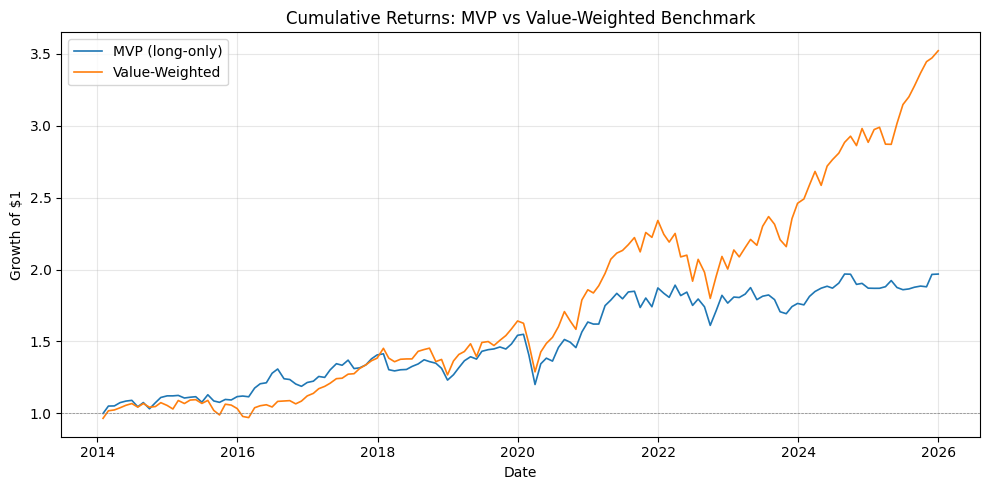

In [52]:
# =============================================================================
# 1. Load monthly market cap data
# =============================================================================

mv_clean = clean_headers(pd.read_csv(CLEAN_DIR / MV_CLEAN_FILE))
_, mv_isin_col = get_id_cols(mv_clean)
mv_month_cols = sort_month_cols(get_time_cols(mv_clean))
mv_by_isin = mv_clean.set_index(mv_isin_col)

# =========================================================================
# 2. Build monthly value-weighted benchmark returns
# =========================================================================

vw_rows = []

for year in range(START_YEAR, END_YEAR + 1):
    investment_year = year + 1

    # Use the same investment universe as in Section 2.1
    investable_isins = investment_set.loc[
        (investment_set["screen_year"] == year)
        & (investment_set["investable_for_next_year"] == True),
        "ISIN"
    ].tolist()

    if not investable_isins:
        continue

    inv_cols = get_investment_year_cols(ret_month_cols, investment_year)
    if not inv_cols:
        continue

    for col in inv_cols:
        current_dt = pd.Timestamp(col)
        prev_month_dt = current_dt - pd.DateOffset(months=1)

        # Use market cap from the previous month to form value weights
        # Match by year-month period instead of exact date to avoid end-of-month mismatch
        target_period   = prev_month_dt.to_period("M")
        prev_candidates = [c for c in mv_month_cols if pd.Timestamp(c).to_period("M") == target_period]
        if not prev_candidates:
            continue

        prev_col = prev_candidates[0]

        caps = mv_by_isin.reindex(investable_isins)[prev_col].apply(pd.to_numeric, errors="coerce")
        rets = ri_ret_by_isin.reindex(investable_isins)[col].apply(pd.to_numeric, errors="coerce")


        # Only keep firms with valid positive market cap
        valid = caps.notna() & rets.notna() & (caps > 0)
        caps = caps[valid]
        rets = rets[valid]

        if caps.empty:
            continue

        weights_vw = caps / caps.sum()
        rp_vw = float((weights_vw * rets).sum())

        vw_rows.append({
            "screen_year": year,
            "investment_year": investment_year,
            "date": current_dt,
            "Rp_vw": rp_vw
        })

vw_monthly_returns = pd.DataFrame(vw_rows).sort_values("date").reset_index(drop=True)

if vw_monthly_returns.empty:
    raise RuntimeError("No value-weighted returns were generated.")

# =============================================================================
# 3. Merge MVP and benchmark returns & load risk-free rate for performance comparison
# =============================================================================

compare_df = (
    mvp_monthly_returns[["date", "Rp_mvp"]]
    .assign(date=lambda x: pd.to_datetime(x["date"]))
    .merge(
        vw_monthly_returns[["date", "Rp_vw"]]
        .assign(date=lambda x: pd.to_datetime(x["date"])),
        on="date",
        how="inner"
    )
    .sort_values("date")
    .set_index("date")
)

if compare_df.empty:
    raise RuntimeError("Merged comparison dataframe is empty.")

# Compute cumulative returns (as growth of $1)
compare_df["cum_mvp"] = (1.0 + compare_df["Rp_mvp"]).cumprod()
compare_df["cum_vw"]  = (1.0 + compare_df["Rp_vw"]).cumprod()


# Load the risk-free rate data
rf_raw = pd.read_csv(RAW_DIR / "Risk_Free_Rate_2025.csv")

# Normalise column names
rf_raw.columns = [str(c).strip() for c in rf_raw.columns]

# Identify date and rate columns (adjust names below if your file uses different headers)
date_col_rf = rf_raw.columns[0]   # first column dates in YYYYMM format
rate_col_rf = rf_raw.columns[1]   # second column rates

# Convert YYYYMM format to datetime (e.g., 200001 -> 2000-01-01)
rf_raw[date_col_rf] = pd.to_datetime(rf_raw[date_col_rf], format='%Y%m')
rf_raw[rate_col_rf] = pd.to_numeric(rf_raw[rate_col_rf], errors="coerce")

# Convert annual percentage rates 
rf_raw["rf_monthly"] = rf_raw[rate_col_rf] / 100 

# Filter to the same period as the portfolio returns
sample_start = pd.to_datetime("2014-01-01")
sample_end   = compare_df.index.max()

rf_in_sample = rf_raw[
    (rf_raw[date_col_rf] >= sample_start) &
    (rf_raw[date_col_rf] <= sample_end)
]

rf_monthly_avg = rf_in_sample["rf_monthly"].mean()

print(f"Average monthly RF rate: {rf_monthly_avg:.4%}")
print(f"Implied annual RF rate:  {rf_monthly_avg * 12:.4%}")

# =============================================================================
# 4. Compare performance statistics
# =============================================================================

mvp_stats = summary_stats(compare_df["Rp_mvp"], "P(mv)_oos", rf_monthly=rf_monthly_avg)
vw_stats  = summary_stats(compare_df["Rp_vw"],  "P(vw)_oos", rf_monthly=rf_monthly_avg)

comparison_summary = pd.DataFrame([mvp_stats, vw_stats])

# =============================================================================
# 5. Table 1: Performance summary
# =============================================================================

display_df = comparison_summary[
    ["portfolio", "ann_mean_return", "ann_volatility",
     "sharpe_ratio", "min_monthly_return", "max_monthly_return"]
].copy()

display_df.columns = [
    "Portfolio", "Ann. Return", "Ann. Volatility",
    "Sharpe Ratio", "Min Monthly Ret.", "Max Monthly Ret."
]

for col in ["Ann. Return", "Ann. Volatility", "Min Monthly Ret.", "Max Monthly Ret."]:
    display_df[col] = display_df[col].apply(lambda x: f"{x:.2%}")

display_df["Sharpe Ratio"] = display_df["Sharpe Ratio"].apply(lambda x: f"{x:.3f}")

print("\n" + "=" * 72)
print("Table 1 — Performance Summary: MVP vs Value-Weighted Benchmark")
print(f"          Period: {compare_df.index.min().strftime('%b %Y')} to {compare_df.index.max().strftime('%b %Y')}")
print("=" * 72)
print(display_df.to_string(index=False))
print("=" * 72)

# =============================================================================
# 6. Table 2: Number of investable firms by year
# =============================================================================

inv_by_year = (
    investment_set[investment_set["investable_for_next_year"]]
    .groupby("screen_year")["ISIN"]
    .count()
    .rename("N Firms")
    .reset_index()
    .rename(columns={"screen_year": "Screen Year"})
)

print("\n" + "=" * 35)
print("Table 2 — Investable Universe by Year")
print("=" * 35)
print(inv_by_year.to_string(index=False))
print("=" * 35)

# =============================================================================
# 7. Table 3: Largest MVP holdings in first portfolio
# =============================================================================

static = clean_headers(pd.read_csv(RAW_DIR / STATIC_FILE))
isin_col = [c for c in static.columns if c.upper() == 'ISIN'][0]
name_col = [c for c in static.columns if c.upper() == 'NAME'][0]
isin_to_name = dict(zip(static[isin_col], static[name_col]))

first_screen_year = weights_by_year["screen_year"].min()

top10 = (
    weights_by_year[weights_by_year["screen_year"] == first_screen_year]
    .nlargest(10, "weight")[["ISIN", "weight"]]
    .copy()
    .reset_index(drop=True)
)

top10.insert(1, "NAME", top10["ISIN"].map(isin_to_name))

top10.index = range(1, 11)
top10["weight"] = top10["weight"].apply(lambda x: f"{x:.2%}")

print("\n" + "=" * 65)
print(f"Table 3 — Top 10 MVP Holdings (portfolio for {first_screen_year + 1})")
print("=" * 65)
print(top10.to_string(columns=["ISIN", "NAME", "weight"]))
print("=" * 65)

# =============================================================================
# 8. Cumulative return plot
# =============================================================================

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(compare_df.index, compare_df["cum_mvp"], label="MVP (long-only)", linewidth=1.2)
ax.plot(compare_df.index, compare_df["cum_vw"],  label="Value-Weighted", linewidth=1.2)
ax.axhline(1.0, color="grey", linestyle="--", linewidth=0.5)
ax.set_ylabel("Growth of $1")
ax.set_xlabel("Date")
ax.set_title("Cumulative Returns: MVP vs Value-Weighted Benchmark")
ax.legend()
ax.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig(OUT_DIR / "cumulative_returns_plot.png", dpi=300, bbox_inches='tight')
plt.show()

# =============================================================================
# 9. Save outputs
# =============================================================================

vw_monthly_returns.to_csv(OUT_DIR / VW_RET_FILE, index=False)
comparison_summary.to_csv(OUT_DIR / "mvp_vs_vw_performance_summary.csv", index=False)
compare_df.to_csv(OUT_DIR / "mvp_vs_vw_monthly_comparison.csv", index=True)

## Excel Export

For the April 12th deadline

In [53]:
import pandas as pd

# Use the merged comparison dataframe created in Cell 4

mvp_returns = compare_df["Rp_mvp"]
vw_returns  = compare_df["Rp_vw"]

# 1. Summary statistics

mvp_stats = summary_stats(mvp_returns, "MVP", rf_monthly=rf_monthly_avg)
vw_stats  = summary_stats(vw_returns,  "VW",  rf_monthly=rf_monthly_avg)

# Add cumulative return 
mvp_stats["ann_cumulative_return"] = (1 + mvp_returns).prod() - 1
vw_stats["ann_cumulative_return"]  = (1 + vw_returns).prod() - 1

stats_df = pd.DataFrame([vw_stats, mvp_stats])

print("Summary statistics:")
print(stats_df)

# 2. Monthly returns for the template

returns_df = pd.DataFrame({
    "VW": vw_returns,
    "MVP": mvp_returns
})

returns_df.index.name = "Date"

print("\nMonthly returns (first rows):")
print(returns_df.head())

# 3. Export to Excel

stats_df.to_excel(OUT_DIR / "summary_stats.xlsx", index=False)
returns_df.to_excel(OUT_DIR / "monthly_returns.xlsx")

print("\nExcel files exported successfully.")
print(f"Saved in: {OUT_DIR}")

Summary statistics:
  portfolio start_date end_date  n_months  ann_mean_return  ann_volatility  \
0        VW    2014-01  2025-12       144         0.115415        0.141947   
1       MVP    2014-01  2025-12       144         0.063763        0.119617   

   sharpe_ratio  min_monthly_return  max_monthly_return  ann_cumulative_return  
0      0.689980           -0.131327            0.128786               2.522228  
1      0.386969           -0.145537            0.119959               0.968768  

Monthly returns (first rows):
                  VW       MVP
Date                          
2014-01-31 -0.034669 -0.000825
2014-02-28  0.054489  0.051576
2014-03-31  0.005675  0.000945
2014-04-30  0.014889  0.021859
2014-05-30  0.016364  0.009873

Excel files exported successfully.
Saved in: c:\Users\zagor\Vlad\M\Sustainability\Project\Sustainability-Aware-Asset-Management-Project\results


# Part II - Portfolio Allocation with Carbon Emission Reduction
## 3 Allocation with a 50% Reduction in Carbon Emissions
We take into account the CO2 emissions associated to the portfolio. We are only taking Scope 1 emissions, meaning emissions directly created by sources that the company owns. We are not taking Scope 2 given our group assignment.
## 3.1 Carbon Emissions

Computing carbon intensity for each year...
  Year 2013: 837 firms with CI data
  Year 2014: 863 firms with CI data
  Year 2015: 896 firms with CI data
  Year 2016: 918 firms with CI data
  Year 2017: 952 firms with CI data
  Year 2018: 1010 firms with CI data
  Year 2019: 1100 firms with CI data
  Year 2020: 1143 firms with CI data
  Year 2021: 1174 firms with CI data
  Year 2022: 1199 firms with CI data
  Year 2023: 1202 firms with CI data
  Year 2024: 1208 firms with CI data

Computing MVP WACI...
  MVP WACI for 2013: 382.0013 tonnes CO2 / million USD
  MVP WACI for 2014: 643.6024 tonnes CO2 / million USD
  MVP WACI for 2015: 452.4347 tonnes CO2 / million USD
  MVP WACI for 2016: 110.8818 tonnes CO2 / million USD
  MVP WACI for 2017: 307.3810 tonnes CO2 / million USD
  MVP WACI for 2018: 793.9913 tonnes CO2 / million USD
  MVP WACI for 2019: 525.4308 tonnes CO2 / million USD
  MVP WACI for 2020: 437.7208 tonnes CO2 / million USD
  MVP WACI for 2021: 249.6519 tonnes CO2 / million USD

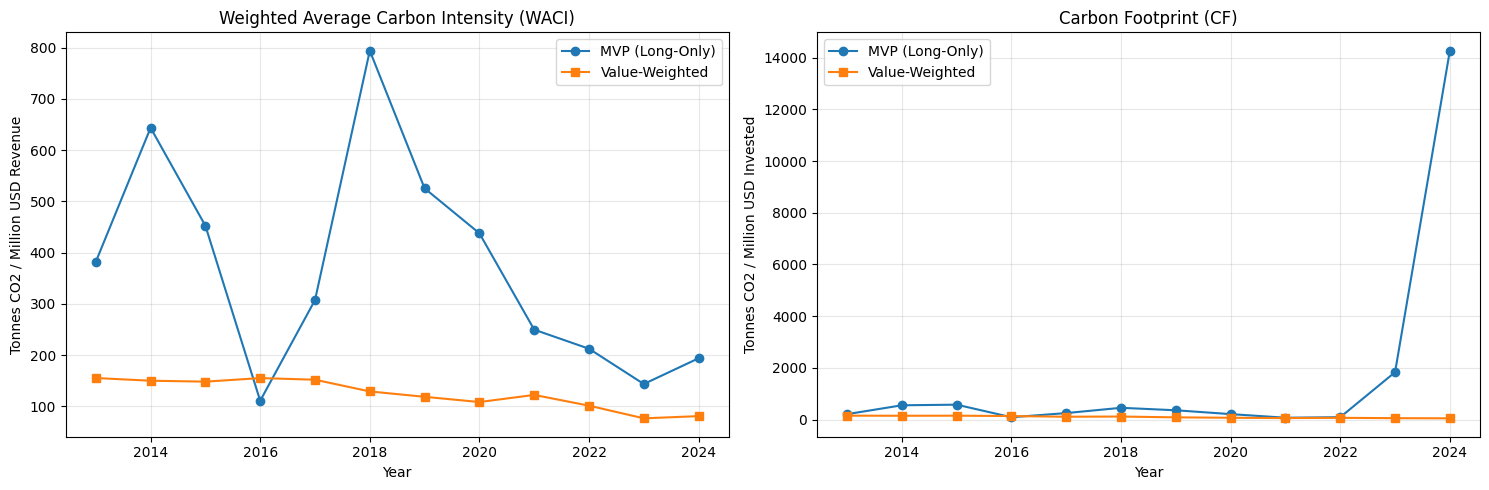

In [ ]:
# =============================================================================
# 1. Compute carbon intensity for all firms in investment set
# =============================================================================
date_cols_mv = sort_month_cols(get_time_cols(mv_clean))

carbon_intensity_by_year = {}  # {year: {isin: CI_i,Y}}

# Get all years where we have CO2 and revenue data
year_cols = sort_year_cols([c for c in co2_clean.columns if c.isdigit()])

print("Computing carbon intensity for each year...")

for year_str in year_cols:
    year = int(year_str)
    if START_YEAR <= year <= END_YEAR:
        carbon_intensity_by_year[year] = {}
        
        for isin in co2_clean.index:
            co2_val = co2_clean.loc[isin, year_str] if year_str in co2_clean.columns else np.nan
            rev_val = rev_clean.loc[isin, year_str] if year_str in rev_clean.columns else np.nan
            
            if pd.notna(co2_val) and pd.notna(rev_val) and rev_val > 0:
                # CO2 in tonnes, Revenue in thousands -> divide by 1000 to get per million
                ci = co2_val / (rev_val / 1000.0)
                carbon_intensity_by_year[year][isin] = ci
        
        print(f"  Year {year}: {len(carbon_intensity_by_year[year])} firms with CI data")

# =============================================================================
# 2. Compute WACI for MVP portfolio
# =============================================================================

mvp_waci_by_year = {}

print("\nComputing MVP WACI...")

for year in range(START_YEAR, END_YEAR + 1):
    # Get weights for this year from weights_by_year
    year_weights = weights_by_year[weights_by_year["screen_year"] == year]
    
    if year_weights.empty:
        mvp_waci_by_year[year] = np.nan
        continue
    
    waci = 0.0
    for _, row in year_weights.iterrows():
        isin = row["ISIN"]
        weight = row["weight"]
        ci = carbon_intensity_by_year.get(year, {}).get(isin, 0.0)
        waci += weight * ci
    
    mvp_waci_by_year[year] = waci
    print(f"  MVP WACI for {year}: {waci:.4f} tonnes CO2 / million USD")

# =============================================================================
# 3. Compute WACI for Value-Weighted portfolio
# =============================================================================

vw_waci_by_year = {}

print("\nComputing VW WACI...")

for year in range(START_YEAR, END_YEAR + 1):
    # Get market caps for year-end
    year_end_dt = pd.Timestamp(f"{year}-12-31")

    closest_col = min(
        date_cols_mv,
        key=lambda c: abs(pd.Timestamp(c) - year_end_dt)
    )
    if abs(pd.Timestamp(closest_col) - year_end_dt) > pd.Timedelta(days=10):
        print(f"WARNING: {year} year-end cap data {closest_col} is >10 days from 12-31")
    
    # For VW, we use market caps at the rebalance date
    # We need to match this with the same investment universe
    investable_isins = investment_set.loc[
        (investment_set["screen_year"] == year)
        & (investment_set["investable_for_next_year"] == True),
        "ISIN"
    ].tolist()
    
    # Get December year-end market caps
    date_cols_mv = sort_month_cols(get_time_cols(mv_clean))
    year_end_col = [c for c in date_cols_mv if str(year) in c]
    
    if not year_end_col:
        vw_waci_by_year[year] = np.nan
        continue
    
    year_end_col = year_end_col[-1]  # Get the last one if multiple matches
    
    # Get market caps and compute weights
    mv_vals = mv_by_isin.loc[investable_isins, year_end_col].apply(pd.to_numeric, errors='coerce')
    mv_vals = mv_vals.dropna()
    
    total_mv = mv_vals.sum()
    
    if total_mv <= 0:
        vw_waci_by_year[year] = np.nan
        continue
    
    waci = 0.0
    for isin in mv_vals.index:
        weight = mv_vals[isin] / total_mv
        ci = carbon_intensity_by_year.get(year, {}).get(isin, 0.0)
        waci += weight * ci
    
    vw_waci_by_year[year] = waci
    print(f"  VW WACI for {year}: {waci:.4f} tonnes CO2 / million USD")

# =============================================================================
# 4. Identify top 10 carbon drivers
# =============================================================================

print("\n" + "=" * 75)
print("Top 10 Carbon Drivers (Highest Carbon Intensity)")
print("=" * 75)

# Use the most recent year available
latest_year = max(carbon_intensity_by_year.keys())
ci_data = carbon_intensity_by_year[latest_year]

top_10 = sorted(
    [(isin, ci, isin_to_name.get(isin, "N/A")) for isin, ci in ci_data.items()],
    key=lambda x: x[1],
    reverse=True
)[:10]

print(f"\nYear: {latest_year}\n")
print(f"{'Rank':<5} {'ISIN':<15} {'Company Name':<35} {'CI (t CO2/M$)':<15}")
print("-" * 75)
for rank, (isin, ci, name) in enumerate(top_10, 1):
    print(f"{rank:<5} {isin:<15} {name:<35} {ci:>13.2f}")
print("=" * 75)

# =============================================================================
# 5. Summary table: WACI comparison
# =============================================================================

waci_summary = pd.DataFrame({
    "Year": sorted(mvp_waci_by_year.keys()),
    "MVP_WACI": [mvp_waci_by_year.get(y, np.nan) for y in sorted(mvp_waci_by_year.keys())],
    "VW_WACI":  [vw_waci_by_year.get(y, np.nan) for y in sorted(mvp_waci_by_year.keys())],
})

waci_summary["CI_Reduction_%"] = (
    (waci_summary["VW_WACI"] - waci_summary["MVP_WACI"]) / waci_summary["VW_WACI"] * 100
)

print("\n" + "=" * 80)
print("Table: Weighted Average Carbon Intensity (WACI) by Year")
print("=" * 80)
print(waci_summary.to_string(index=False))
print("=" * 80)

# =============================================================================
# 6. Compute Carbon Footprint (CF) for MVP and VW
# =============================================================================
mvp_cf_by_year = {}
vw_cf_by_year = {}

print("\nComputing Carbon Footprints (CF)...")

# Get December market cap columns for lookup
date_cols_mv = sort_month_cols(get_time_cols(mv_clean))

for year in range(START_YEAR, END_YEAR + 1):
    year_str = str(year)
    
    # --- MVP Carbon Footprint ---
    # Assuming $1 Million USD invested: Vy = 1. Therefore o_i = (Weight * 1) / Cap_i
    year_weights = weights_by_year[weights_by_year["screen_year"] == year]
    if year_weights.empty:
        mvp_cf_by_year[year] = np.nan
    else:
        cf_mvp = 0.0
        for _, row in year_weights.iterrows():
            isin = row["ISIN"]
            weight = row["weight"]
            
            co2_val = co2_clean.loc[isin, year_str] if (isin in co2_clean.index and year_str in co2_clean.columns) else np.nan
            
            # Market cap at investment date (December of year)
            year_end_col = [c for c in date_cols_mv if str(year) in c and "-12" in c]
            cap_val = mv_by_isin.loc[isin, year_end_col[-1]] if (year_end_col and isin in mv_by_isin.index) else np.nan
            
            if pd.notna(co2_val) and pd.notna(cap_val) and cap_val > 0:
                cf_mvp += (weight / cap_val) * co2_val
                
        mvp_cf_by_year[year] = cf_mvp
        
    # --- VW Carbon Footprint ---
    investable_isins = investment_set.loc[
        (investment_set["screen_year"] == year) & 
        (investment_set["investable_for_next_year"] == True), "ISIN"
    ].tolist()
    
    year_end_col = [c for c in date_cols_mv if str(year) in c and "-12" in c]
    if not year_end_col or not investable_isins:
        vw_cf_by_year[year] = np.nan
        continue
        
    cap_vals = mv_by_isin.loc[investable_isins, year_end_col[-1]].apply(pd.to_numeric, errors='coerce').dropna()
    total_cap = cap_vals.sum()
    
    if total_cap > 0:
        cf_vw = 0.0
        for isin in cap_vals.index:
            co2_val = co2_clean.loc[isin, year_str] if (isin in co2_clean.index and year_str in co2_clean.columns) else np.nan
            if pd.notna(co2_val):
                cf_vw += (co2_val / total_cap)
        vw_cf_by_year[year] = cf_vw

# Add CF to the summary table
waci_summary["MVP_CF"] = [mvp_cf_by_year.get(y, np.nan) for y in waci_summary["Year"]]
waci_summary["VW_CF"] =  [vw_cf_by_year.get(y, np.nan) for y in waci_summary["Year"]]

print(waci_summary[["Year", "MVP_CF", "VW_CF"]].to_string(index=False))

# =============================================================================
# 7. Plot WACI and CF Comparisons
# =============================================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# WACI Plot
ax1.plot(waci_summary["Year"], waci_summary["MVP_WACI"], marker='o', label="MVP (Long-Only)")
ax1.plot(waci_summary["Year"], waci_summary["VW_WACI"], marker='s', label="Value-Weighted")
ax1.set_title("Weighted Average Carbon Intensity (WACI)")
ax1.set_ylabel("Tonnes CO2 / Million USD Revenue")
ax1.set_xlabel("Year")
ax1.legend()
ax1.grid(True, alpha=0.3)

# CF Plot
ax2.plot(waci_summary["Year"], waci_summary["MVP_CF"], marker='o', label="MVP (Long-Only)")
ax2.plot(waci_summary["Year"], waci_summary["VW_CF"], marker='s', label="Value-Weighted")
ax2.set_title("Carbon Footprint (CF)")
ax2.set_ylabel("Tonnes CO2 / Million USD Invested")
ax2.set_xlabel("Year")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
fig.savefig(OUT_DIR / "carbon_metrics_plot.png", dpi=300, bbox_inches='tight')
plt.show()